In [1]:
import lightning_vocoders
from transformers import Wav2Vec2FeatureExtractor, AutoModel
from lightning_vocoders.models.hifigan.lightning_module import HiFiGANLightningModule
import librosa
import torch
import numpy as np
import pandas as pd
from IPython.display import Audio, display

In [2]:
import panphon

arpa_ipa = {'aa': 'ɑ', 'ae': 'æ', 'ah': 'ʌ', 'ao': 'ɔ', 'aw': 'aʊ', 'ax': 'ə', 'ax-h': 'ə̥', 'axr': 'ɚ', 'ay': 'aɪ', 'b': 'b', 'ch': 'tʃ', 'd': 'd', 'dh': 'ð', 'dx': 'ɾ', 'eh': 'ɛ', 'el': 'l̩', 'em': 'm̩', 'en': 'n̩', 'eng': 'ŋ̍', 'er': 'ɝ', 'ey': 'eɪ', 'f': 'f', 'g': 'ɡ', 'hh': 'h', 'hv': 'ɦ', 'ih': 'ɪ', 'ix': 'ɨ', 'iy': 'i', 'jh': 'dʒ', 'k': 'k', 'l': 'l', 'm': 'm', 'n': 'n', 'ng': 'ŋ', 'nx': 'ɾ̃', 'ow': 'oʊ', 'oy': 'ɔɪ', 'p': 'p', 'r': 'ɹ', 's': 's', 'sh': 'ʃ', 't': 't', 'th': 'θ', 'uh': 'ʊ', 'uw': 'u', 'ux': 'ʉ', 'v': 'v', 'w': 'w', 'y': 'j', 'z': 'z', 'zh': 'ʒ'}

panphon_feats = ['cons', 'hi', 'lo', 'back', 'round', 'voi', 'cont', 'delrel', 'strid', 'nas', 'lat', 'lab', 'cor', 'ant']
ft = panphon.FeatureTable()
ipa_feat = {}
for ipa in arpa_ipa.values():
    arr = ft.word_array(panphon_feats, ipa)
    if len(arr):
        ipa_feat[ipa] = arr[0]
    else:
        ipa_feat[ipa] = np.full(len(panphon_feats), np.nan)

In [3]:
import parselmouth

def voicingness(y, l, r, sr):
    snd = parselmouth.Sound(values=y, sampling_frequency=sr)
    pitch = snd.to_pitch()
    pitch_values = pitch.selected_array["frequency"]

    ratio = len(pitch_values) / len(y)
    pitch_values = pitch_values[int(ratio * l * sr):int(ratio * r * sr)]
    return np.mean(pitch_values > 0)


def formants(y, l, r, sr):
    snd = parselmouth.Sound(values=y, sampling_frequency=sr)
    formant = snd.to_formant_burg()
    times = snd.xs()

    f1 = np.array([formant.get_value_at_time(1, t) for t in times if l < t < r])
    f2 = np.array([formant.get_value_at_time(2, t) for t in times if l < t < r])
    f3 = np.array([formant.get_value_at_time(3, t) for t in times if l < t < r])

    return np.mean(f1), np.mean(f2), np.mean(f3)


def cog(y, l, r, sr):
    snd = parselmouth.Sound(values=y, sampling_frequency=sr)
    segment = snd.extract_part(from_time=l, to_time=r, preserve_times=False)
    return segment.to_spectrum().get_center_of_gravity()

In [4]:
processor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-large")
src = AutoModel.from_pretrained("microsoft/wavlm-large")
tgt = HiFiGANLightningModule.load_from_checkpoint(
    lightning_vocoders.MODEL_URLS["wavlm-large"], map_location="cpu")

def _get_audio(path):
    x, _ = librosa.load(path, sr=16000, mono=True)
    return x

def _get_feats(x, device="cpu"):
    x_norm = processor(raw_speech=[x], sampling_rate=16000, padding=False, return_tensors="pt")
    outputs = src(**{k: t.to(device) for k, t in x_norm.items()})
    return outputs.last_hidden_state.to(device)

def _synth_audio(feats):
    x_hat = tgt.generator(feats)
    x_hat = x_hat.to("cpu").flatten().detach().numpy()
    return x_hat

/home/kwanghec/unbox-w2v-convnet/envs/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
df = pd.read_pickle("../data/timit-slice-wavlm-large-24.pkl")
df.allophone = df.allophone.apply(arpa_ipa.get)
df["avg_feat"] = df.feat.apply(lambda emb: emb.mean(0))
for i, feat in enumerate(panphon_feats):
    df[feat] = df.allophone.apply(lambda ipa: ipa_feat[ipa][i])

def _avg(allophone):
    return np.array(df[df.allophone == allophone].avg_feat.tolist()).mean(0)

def _get_window(tup, ws=1, sr=16000):
    _df = df[df.audio_path == tup.audio_path].sort_values(by="min")
    loc = _df.index.get_loc(tup.Index)
    assert ws <= loc < (len(_df) - ws)
    left = _df.iloc[loc-ws]["min"]
    right = _df.iloc[loc+ws]["max"]
    return int(sr * left), int(sr * tup.min), int(sr * tup.max), int(sr * right)

In [6]:
def show_spectrogram(y, sr, l=None, r=None):
    max_freq, window_length = 5000, 0.005
    snd = parselmouth.Sound(y, sampling_frequency=sr)
    spectrogram = snd.to_spectrogram(window_length=window_length, maximum_frequency=max_freq)
    values = 10 * np.log10(spectrogram.values + 1e-10)

    max_dB = np.max(values)
    # min_dB = max_dB - 50.0  # 50 dB dynamic range
    min_dB = max_dB - 70.0

    plt.figure(figsize=(5, 3))
    plt.imshow(values,
               aspect='auto',
               extent=[0, len(y) / sr, 0, max_freq],
               cmap="gray_r",
               origin="lower",
               vmin=min_dB, vmax=max_dB)
    if l is not None:
        plt.axvline(l, color="red")
        plt.axvline(r, color="red")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    # plt.colorbar(label="Amplitude (dB)")
    plt.show()
    # plt.title("Spectrogram (Parselmouth/Praat)")
    # plt.tight_layout()
    # plt.savefig(output_file, dpi=150)
    # plt.close()

In [7]:
# steering = _avg("s") - _avg("t")
# steering = _avg("s") - _avg("p")
# steering = _avg("tʃ") - _avg("ʃ")
steering = _avg("p") - _avg("ɨ")


# steering = _avg("p") - _avg("f")
# steering = _avg("u") - _avg("ɔ")
# steering = _avg("oʊ") - _avg("eɪ")
# steering = _avg("ʉ") - _avg("ɨ")
# steering = _avg("æ") - _avg("i")
# steering = _avg("p") - _avg("b")
# steering = _avg("d") - _avg("b")
# steering = _avg("b") - _avg("d")
# steering = _avg("ɡ") - _avg("b")
# steering = _avg("t") - _avg("p")

Original (423.09532855002567)


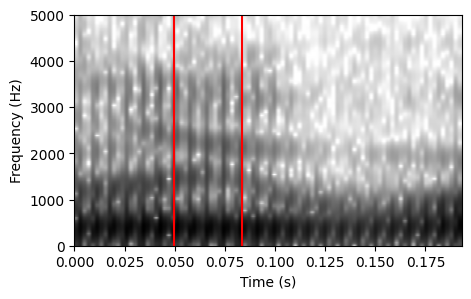

/home/kwanghec/unbox-w2v-convnet/envs/lib/python3.10/site-packages/torch/nn/functional.py:4999: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Synthesized (724.5706471379582)


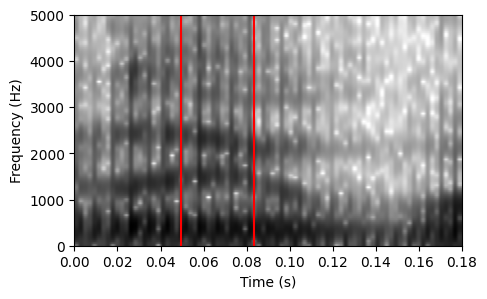

Synthesized + 0.25 Steering (705.3409551534079)


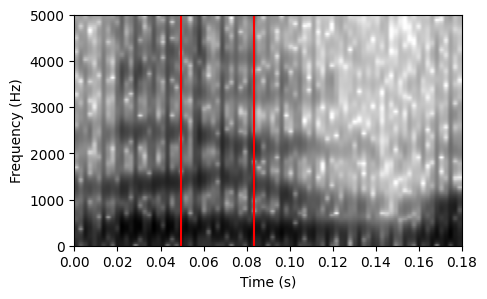

Synthesized + 0.5 Steering (582.7297736186285)


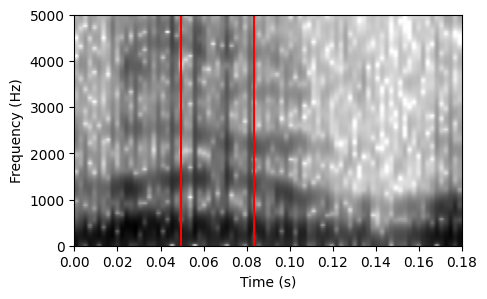

Synthesized + 0.75 Steering (749.7164707189086)


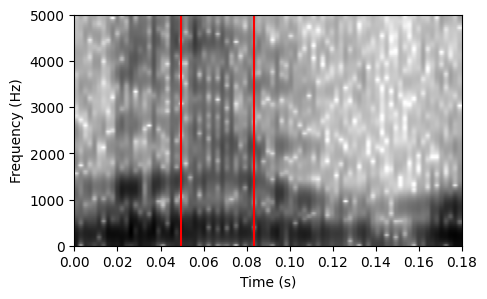

Synthesized + 1.0 Steering (891.0880233189536)


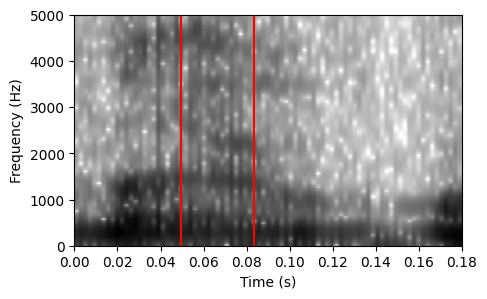

Synthesized + 2.0 Steering (645.7902538191403)


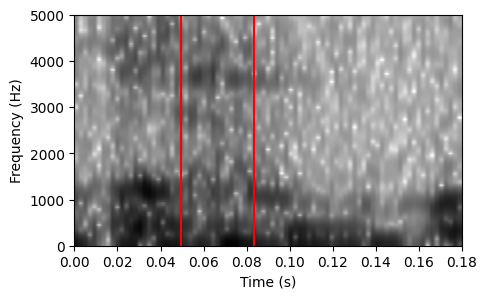

Synthesized + 2.5 Steering (801.6777456467261)


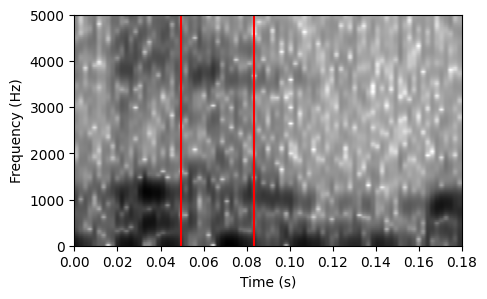

Synthesized + 3.0 Steering (1294.3976373485123)


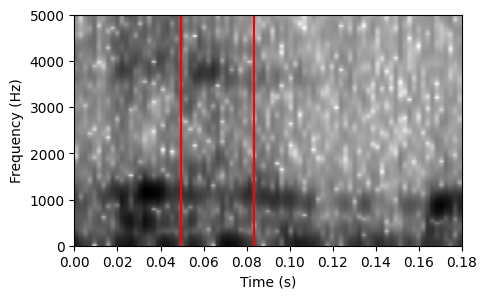

Synthesized + 3.5 Steering (1703.839185448046)


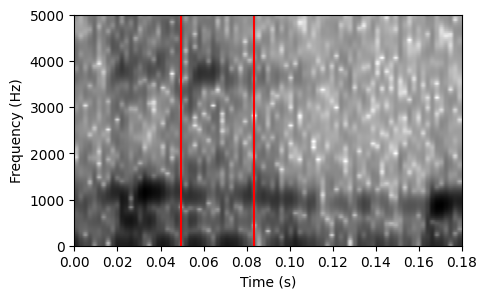

Synthesized + 4.0 Steering (1845.140934553255)


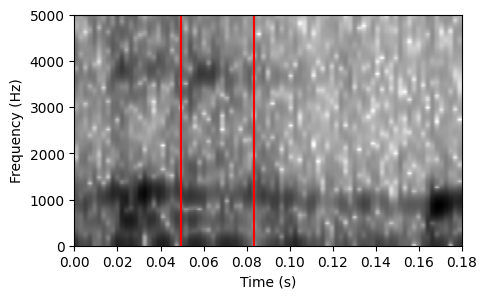

In [8]:
import librosa
import librosa.display
import matplotlib.pyplot as plt


# for tup in df[df.allophone == "u"].sample(n=10, random_state=42).itertuples():
# for tup in df[df.allophone == "d"].sample(n=10, random_state=42).itertuples():
# for tup in df[df.allophone == "k"].sample(n=10, random_state=42).itertuples():
# for tup in df[df.allophone == "p"].sample(n=10, random_state=42).itertuples():
# for tup in df[df.allophone == "ɛ"].sample(n=10, random_state=42).itertuples():
# for tup in df[df.allophone == "ɛ"].sample(n=10, random_state=41).itertuples():
# for tup in df[df.allophone == "ɔ"].sample(n=10, random_state=42).itertuples():
# for tup in df[df.allophone == "ɡ"].sample(n=10, random_state=42).itertuples():
# for tup in df[df.allophone == "s"].sample(n=10, random_state=45).itertuples():
# for tup in df[df.allophone == "t"].sample(n=10, random_state=45).itertuples():
for tup in df[df.allophone == "ɨ"].sample(n=10, random_state=43).itertuples():
    x = _get_audio(tup.audio_path)
    try:
        ll, l, r, rr = _get_window(tup)
    except AssertionError:
        continue
    # print(f"Original ({voicingness(x, ll/16000, rr/16000, 16000)})")
    # print(f"Original ({formants(x, l / 16000, r / 16000, 16000)})")
    print(f"Original ({cog(x, l / 16000, r / 16000, 16000)})")
    show_spectrogram(x[ll:rr], 16000, (l-ll)/16000, (r-ll)/16000)
    display(Audio(x[ll:rr], rate=16000))

    feats = _get_feats(x[ll:rr])
    audio = _synth_audio(feats)
    # print(f"Synthesized ({voicingness(audio, 0, len(audio) / 22050, 22050)})")
    # print(f"Synthesized ({formants(audio, (l-ll)/16000, (r-ll)/16000, 22050)})")
    print(f"Synthesized ({cog(audio, (l-ll)/16000, (r-ll)/16000, 22050)})")
    show_spectrogram(audio, 22050, (l-ll)/16000, (r-ll)/16000)
    display(Audio(audio, rate=22050))

    for alpha in (0.25, 0.5, 0.75, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0):
        audio = _synth_audio(feats + torch.FloatTensor(steering) * alpha)

        # print(f"Synthesized + {alpha} Steering ({voicingness(audio, 0, len(audio) / 22050, 22050)})")
        # print(f"Synthesized + {alpha} Steering ({formants(audio, (l-ll)/16000, (r-ll)/16000, 22050)})")
        print(f"Synthesized + {alpha} Steering ({cog(audio, (l-ll)/16000, (r-ll)/16000, 22050)})")
        show_spectrogram(audio, 22050, (l-ll)/16000, (r-ll)/16000)
        display(Audio(audio, rate=22050))
        # print(voicingness
    break